# EfficientNet-B4 — Tuned 224×224 Experiment

**EEEM068 Applied Machine Learning — Individual LSA Coursework**

This notebook evaluates one tuned EfficientNet-B4 configuration using the
same leakage-free patient-grouped split as the initial baseline.

The experiment keeps the image resolution at 224×224 while replacing
WeightedRandomSampler and focal loss with clipped class-weighted
cross-entropy. It also uses P1 preprocessing, moderate augmentation,
validation-based learning-rate reduction and stricter early stopping.

### What changed relative to the baseline, and why

`01_experiment_tracking` in this project compares controlled, single-variable changes rather
than a single "kitchen sink" experiment, so it's possible to say *which* change helped. This
notebook (`exp02`) changes five things at once relative to the baseline (`exp01`) —
preprocessing, sampler, loss, scheduler, early stopping — which means it should be read as
**one alternative recipe to compare against the baseline**, not as an ablation in itself. If
this recipe outperforms the baseline, a follow-up notebook would be needed to isolate which
of these five changes actually mattered.

The baseline (`exp01_shared_p0_wrs_focal_seed42`) combined `WeightedRandomSampler` with focal
loss, which doubly over-corrected for class imbalance — this showed up directly in its
results as very low precision on the "Mild" class (0.094) despite reasonable recall, i.e. the
model called things "Mild" far more often than it should have. This notebook removes one of
the two rebalancing mechanisms (WRS) and replaces the other (focal loss) with **clipped
class-weighted cross-entropy** — weighting is still present, but bounded to `[0.5, 2.5]` so no
class can dominate the gradient the way uncapped inverse-frequency weighting would.

Preprocessing moves from **P0** to **P1** (Ben Graham local-contrast enhancement added before
padding), and augmentation is deliberately toned down — no vertical flips, no large rotation,
no random erasing — since diabetic retinopathy images do not naturally appear upside-down or
paint-spattered, and overly aggressive augmentation can slow convergence without a clear
benefit on a dataset this size.

Early stopping uses separate patience budgets for each phase (PHASE1_PATIENCE=3 and PHASE2_PATIENCE=4). The patience counter resets only when validation QWK improves by more than EARLY_STOPPING_MIN_DELTA=0.002, preventing small numerical fluctuations from extending training. Checkpoint saving remains more sensitive: any genuine improvement in validation QWK is saved, with validation macro F1 used as the tie-break when QWK values are equal.

## 1. Imports

Identical to the baseline's import list. `cv2` is still needed for P1 preprocessing (border
crop + Ben Graham + padding), and the full `sklearn.metrics` set is still used for the same
metric suite (accuracy, balanced accuracy, macro-F1, QWK, per-class precision/recall).

In [1]:
import json
import random
from pathlib import Path

import cv2
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
)

from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

print("Imports OK.")

Imports OK.


## 2. Configuration and output paths

`RUN_ID` changes to `exp02_p1_clipped_weighted_ce_earlystop_seed42` so this experiment writes
to its own logs/checkpoints/figures directories and never overwrites Experiment 01. Everything
else that stays comparable across experiments — `MODEL_NAME`, `IMAGE_SIZE`, `BATCH_SIZE`,
`SEED` — is intentionally left unchanged, since the point of a controlled comparison is to
change the training recipe, not the things that would make the comparison unfair.

Early stopping now has **separate patience budgets per phase**
(`PHASE1_PATIENCE`, `PHASE2_PATIENCE`) plus a minimum-improvement threshold
(`EARLY_STOPPING_MIN_DELTA`) — see Sections 13/15 for how this is used.

In [2]:
PROJECT_ROOT = Path(
    "/scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy"
)

SPLITS_DIR = PROJECT_ROOT / "configs" / "splits"

TRAIN_CSV = SPLITS_DIR / "train_split.csv"
VAL_CSV = SPLITS_DIR / "val_split.csv"
TEST_CSV = SPLITS_DIR / "internal_test_split.csv"

MODEL_NAME = "efficientnet_b4"
RUN_ID = "exp02_p1_clipped_weighted_ce_earlystop_seed42"

RUN_LOG_DIR = PROJECT_ROOT / "logs" / MODEL_NAME / RUN_ID
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / MODEL_NAME / RUN_ID
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / MODEL_NAME / RUN_ID
PREDICTION_DIR = PROJECT_ROOT / "results" / "predictions"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"

for directory in [
    RUN_LOG_DIR,
    CHECKPOINT_DIR,
    FIGURE_DIR,
    PREDICTION_DIR,
    TABLE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

SEED = 42

NUM_CLASSES = 5
CLASS_NAMES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR",
]

PREPROCESSING = "P1"

IMAGE_SIZE = 224
IMGNET_MEAN = (0.485, 0.456, 0.406)
IMGNET_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 16

PHASE1_EPOCHS = 8
PHASE2_EPOCHS = 20

PHASE1_PATIENCE = 3
PHASE2_PATIENCE = 4
EARLY_STOPPING_MIN_DELTA = 0.002

PHASE1_HEAD_LR = 3e-4
PHASE2_HEAD_LR = 1e-4
PHASE2_BACKBONE_LR = 1e-5

WEIGHT_DECAY = 1e-2
DROPOUT = 0.3
NUM_WORKERS = 4
GRAD_CLIP = 1.0

CLASS_WEIGHT_CLIP = (0.5, 2.5)
LABEL_SMOOTHING = 0.05

PHASE1_BEST_PATH = CHECKPOINT_DIR / "phase1_best.pt"
FINAL_BEST_PATH = CHECKPOINT_DIR / "best_model.pt"

print(f"Run          : {MODEL_NAME}/{RUN_ID}")
print(f"Logs         -> {RUN_LOG_DIR}")
print(f"Checkpoints  -> {CHECKPOINT_DIR}")
print(f"Figures      -> {FIGURE_DIR}")

Run          : efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42
Logs         -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42
Checkpoints  -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/checkpoints/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42
Figures      -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42


## 3. Reproducibility and device

Unchanged from the baseline: full seeding across Python/NumPy/PyTorch/CUDA, a seeded
per-worker RNG for `DataLoader` workers, and a hard failure if no CUDA GPU is available —
this notebook should never silently start training on CPU.

In [3]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

if device.type != "cuda":
    raise RuntimeError(
        "CUDA GPU is not available. Do not start this training run on CPU."
    )

Device: cuda
GPU: NVIDIA RTX A4000


## 4. Load and validate the patient-grouped splits

Exactly the same split files and the same validation as Experiment 01 —
`train_split.csv` / `val_split.csv` / `internal_test_split.csv` from
`01_data_preparation.ipynb`, re-checked for required columns, missing files, total row count,
and patient-level leakage. No new split is created here: both experiments must be evaluated
on the same held-out data for the comparison between them to mean anything.

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

required_columns = {
    "image",
    "level",
    "patient_id",
    "eye",
    "filepath",
}

for split_name, frame in [
    ("train", train_df),
    ("validation", val_df),
    ("internal test", test_df),
]:
    missing_columns = required_columns - set(frame.columns)

    if missing_columns:
        raise ValueError(
            f"{split_name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    missing_files = frame.loc[
        ~frame["filepath"].map(
            lambda path: Path(path).exists()
        )
    ]

    if len(missing_files) > 0:
        raise FileNotFoundError(
            f"{split_name} contains "
            f"{len(missing_files):,} missing image files."
        )

assert len(train_df) + len(val_df) + len(test_df) == 35_126

train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

print(f"Train         : {len(train_df):,}")
print(f"Validation    : {len(val_df):,}")
print(f"Internal test : {len(test_df):,}")
print("Patient leakage check: PASSED")

Train         : 24,586
Validation    : 5,270
Internal test : 5,270
Patient leakage check: PASSED


## 5. P1 preprocessing

This experiment uses **P1**, not P0: load as RGB, crop the black border, apply Ben Graham
local-contrast enhancement, pad onto a centred square, then resize to 224×224. Ben Graham is
applied *before* padding (matching the fix already made in `01_data_preparation.ipynb`), so
the enhancement filter never sees — and never amplifies — the artificial black border. This
is the one preprocessing variant deliberately excluded from the baseline, and comparing
`exp01` (P0) against `exp02` (P1) is one of the axes this project's comparison is meant to
cover.

In [5]:
def _load_rgb(path: str) -> np.ndarray:
    """Load an image file and return it as an RGB uint8 array."""
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise ValueError(f"Cannot decode image: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def _crop_black_borders(img: np.ndarray, threshold: int = 10) -> np.ndarray:
    """Crop the uninformative black padding around the retinal disc."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    margin = int(min(w, h) * 0.02)
    x, y = max(0, x - margin), max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)
    return img[y:y + h, x:x + w]


def _pad_square(img: np.ndarray) -> np.ndarray:
    """Pad an image onto a centred square canvas (no resizing yet)."""
    h, w = img.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img.dtype)
    y = (side - h) // 2
    x = (side - w) // 2
    canvas[y:y + h, x:x + w] = img
    return canvas


def _common_preprocessing(image_path: str) -> np.ndarray:
    """Load the RGB image and crop the black outer border."""
    img = _load_rgb(image_path)
    img = _crop_black_borders(img)
    return img


def ben_graham(img: np.ndarray, sigma: float = 10) -> np.ndarray:
    """Ben Graham local-contrast enhancement (Kaggle DR competition winner's technique)."""
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    return cv2.addWeighted(img, 4, blurred, -4, 128)


def preprocess_p1(image_path: str, output_size: int = IMAGE_SIZE, sigma: float = 10) -> np.ndarray:
    """P1: crop black borders, Ben Graham enhancement, pad to square, resize."""
    img = _common_preprocessing(image_path)
    img = ben_graham(img, sigma=sigma)
    img = _pad_square(img)
    return cv2.resize(
        img,
        (output_size, output_size),
        interpolation=cv2.INTER_AREA,
    )


print(f"P1 preprocessing ready. Output size: {IMAGE_SIZE}x{IMAGE_SIZE}, RGB, uint8.")

P1 preprocessing ready. Output size: 224x224, RGB, uint8.


## 6. Dataset and transformations

`DRDataset` is unchanged in structure from the baseline — it reads `filepath` directly from
the manifest and returns `(image, label, index)` so predictions can be matched back to their
source row later (Section 19). The only difference here is that `__getitem__` calls
`preprocess_p1` instead of `preprocess_p0`.

**Augmentation is deliberately moderate.** Compared to the baseline's transform, this removes
`RandomErasing`, vertical flips, large ±30° rotation and aggressive random-crop resizing —
replaced by a horizontal flip, a small ±10° rotation, and mild colour jitter. Retinal fundus
images are never naturally upside-down, so vertical flips add a transformation the model will
never see at inference time; and large rotations combined with random cropping can crop useful
retinal detail out of frame. The evaluation transform is a plain resize + normalize, with no
augmentation at all.

In [6]:
class DRDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        transform=None,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int):
        row = self.df.iloc[index]

        image = preprocess_p1(row["filepath"])
        image = Image.fromarray(image)

        label = int(row["level"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label, index

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=10,
        interpolation=transforms.InterpolationMode.BILINEAR,
    ),

    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08,
        saturation=0.04,
        hue=0.0,
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMGNET_MEAN,
        std=IMGNET_STD,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMGNET_MEAN,
        std=IMGNET_STD,
    ),
])

train_ds = DRDataset(
    train_df,
    transform=train_transform,
)

val_ds = DRDataset(
    val_df,
    transform=eval_transform,
)

test_ds = DRDataset(
    test_df,
    transform=eval_transform,
)

print(f"train_ds: {len(train_ds):,} | val_ds: {len(val_ds):,} | test_ds: {len(test_ds):,}")

train_ds: 24,586 | val_ds: 5,270 | test_ds: 5,270


## 7. DataLoaders — plain shuffling, no WeightedRandomSampler

The baseline used `WeightedRandomSampler` on top of an already-rebalancing loss, which is what
produced its very low "Mild" precision. This experiment removes WRS entirely: the training
loader uses ordinary `shuffle=True`, and class imbalance is instead handled once, inside the
loss function (Section 9), where its effect is bounded (`CLASS_WEIGHT_CLIP`) rather than
compounding with a second rebalancing mechanism. Validation and internal-test loaders remain
`shuffle=False`, unchanged — evaluation should always reflect each partition's natural class
distribution.

In [8]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
)

print(
    f"Train batches: {len(train_loader)} | "
    f"Val batches: {len(val_loader)} | "
    f"Test batches: {len(test_loader)}"
)

Train batches: 1537 | Val batches: 330 | Test batches: 330


## 8. EfficientNet-B4 model

Unchanged from the baseline: EfficientNet-B4 pretrained on ImageNet-1K with the backbone's own
classifier removed and a small `LayerNorm -> Dropout -> Linear` head attached in its place.
Parameter count is computed from the live model rather than hard-coded, so it stays correct
regardless of `timm` version.

In [9]:
def build_efficientnet_model(pretrained: bool = True) -> nn.Module:
    """Build EfficientNet-B4 with a custom 5-class classification head."""
    backbone = timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=0,
        global_pool="avg",
    )
    feat_dim = backbone.num_features

    backbone.custom_head = nn.Sequential(
        nn.LayerNorm(feat_dim),
        nn.Dropout(p=DROPOUT),
        nn.Linear(feat_dim, NUM_CLASSES),
    )

    _base_forward = backbone.forward
    backbone.forward = lambda x: backbone.custom_head(_base_forward(x))

    return backbone


model = build_efficientnet_model(pretrained=True).to(device)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_parameters:,}")

Model: efficientnet_b4
Total parameters: 17,561,165


## 9. Clipped class-weighted cross-entropy and two-phase optimisation setup

**No focal loss, no WRS.** Class weights are computed as `len(train_df) / (NUM_CLASSES *
class_counts)` — the standard inverse-frequency weighting — but then **clipped to
`[0.5, 2.5]`** before being handed to `nn.CrossEntropyLoss`. Clipping matters here: uncapped
inverse-frequency weighting on this dataset would give "Proliferative DR" (507 training
images) a weight roughly 35× that of "No DR" (18,062 images), which tends to make the model
over-call the rarest classes — exactly the "Mild" over-prediction problem seen in the
baseline, just moved to a different class. Clipping bounds how far any one class can dominate
the gradient. `label_smoothing=0.05` is also added, which softens the target distribution
slightly and tends to reduce over-confident wrong predictions.

Two-phase training itself is unchanged: Phase 1 trains only the head with the backbone frozen,
Phase 2 unfreezes everything with a lower backbone learning rate than head learning rate.

In [10]:
class_counts = (
    train_df["level"]
    .value_counts()
    .sort_index()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .to_numpy()
)

if np.any(class_counts == 0):
    raise RuntimeError(
        f"At least one class has zero training samples: {class_counts}"
    )

class_weights = len(train_df) / (
    NUM_CLASSES * class_counts
)

class_weights = np.clip(
    class_weights,
    CLASS_WEIGHT_CLIP[0],
    CLASS_WEIGHT_CLIP[1],
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device,
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=LABEL_SMOOTHING,
)

print("Training class counts :", class_counts)
print("Clipped class weights :", class_weights)
print("Loss                    : Weighted Cross-Entropy")
print("Label smoothing         : 0.05")


def freeze_backbone(model: nn.Module) -> None:
    """Freeze all parameters except the custom_head."""
    for name, param in model.named_parameters():
        param.requires_grad = ("custom_head" in name)


def unfreeze_all(model: nn.Module) -> None:
    """Unfreeze all parameters."""
    for param in model.parameters():
        param.requires_grad = True


freeze_backbone(model)
trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 1 trainable params: {trainable_p1:,} (head only, backbone frozen)")

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=PHASE1_EPOCHS
)

Training class counts : [18062  1709  3698   610   507]
Clipped class weights : [0.5        2.5        1.32969173 2.5        2.5       ]
Loss                    : Weighted Cross-Entropy
Label smoothing         : 0.05
Phase 1 trainable params: 12,549 (head only, backbone frozen)


## 10. Metric and epoch functions

Identical to the baseline's hardened `run_epoch()`: it raises if a training call is made
without an optimizer, disables gradient tracking entirely during evaluation
(`torch.set_grad_enabled(train_mode)`), guards against an empty loader, and raises if QWK
comes back non-finite. It returns loss, accuracy, balanced accuracy, macro-F1, QWK, and the
raw per-sample labels/predictions/probabilities/indices needed for later analysis and for
matching predictions back to source rows.

One addition beyond the baseline: a `head_only` flag. Freezing a parameter's `requires_grad`
stops gradients from flowing into it, but it does **not** stop `BatchNorm` layers from
updating their running mean/variance during a `model.train()` forward pass — those statistics
update regardless of whether the layer's weights are trainable. `set_batchnorm_eval()` forces
every `BatchNorm` module into `eval()` mode (frozen running stats, no dropout-style
randomness) whenever `head_only=True`, so Phase 1's "frozen backbone" is actually frozen, not
just gradient-frozen.

In [11]:
use_amp = device.type == "cuda"

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp,
)


def set_batchnorm_eval(module: nn.Module) -> None:
    """Prevent BatchNorm running statistics changing in Phase 1."""
    if isinstance(
        module,
        nn.modules.batchnorm._BatchNorm,
    ):
        module.eval()


def run_epoch(
    loader,
    optimizer=None,
    train_mode: bool = True,
    grad_clip: float = GRAD_CLIP,
    head_only: bool = False,
):
    """Run one complete training or evaluation epoch."""

    if train_mode and optimizer is None:
        raise ValueError(
            "An optimizer must be supplied during training."
        )

    if train_mode:
        model.train()

        if head_only:
            model.apply(set_batchnorm_eval)
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_preds = []
    all_probs = []
    all_indices = []

    description = "train" if train_mode else "eval"

    for images, labels, indices in tqdm(
        loader,
        leave=False,
        desc=description,
    ):
        images = images.to(
            device,
            non_blocking=True,
        )
        labels = labels.to(
            device,
            non_blocking=True,
        )

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            with torch.autocast(
                device_type=device.type,
                enabled=use_amp,
            ):
                logits = model(images)
                loss = criterion(logits, labels)

        if train_mode:
            scaler.scale(loss).backward()

            if grad_clip > 0:
                scaler.unscale_(optimizer)

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    grad_clip,
                )

            scaler.step(optimizer)
            scaler.update()

        probabilities = F.softmax(
            logits.detach(),
            dim=1,
        )

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_preds.extend(
            probabilities.argmax(dim=1).cpu().tolist()
        )
        all_labels.extend(
            labels.detach().cpu().tolist()
        )
        all_probs.extend(
            probabilities.cpu().tolist()
        )
        all_indices.extend(
            indices.cpu().tolist()
        )

    if total_samples == 0:
        raise RuntimeError(
            "The DataLoader produced no samples."
        )

    epoch_qwk = cohen_kappa_score(
        all_labels,
        all_preds,
        weights="quadratic",
    )

    if not np.isfinite(epoch_qwk):
        raise RuntimeError(
            "QWK became NaN or infinity during the epoch."
        )

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy_score(
            all_labels,
            all_preds,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            all_labels,
            all_preds,
        ),
        "macro_f1": f1_score(
            all_labels,
            all_preds,
            average="macro",
            zero_division=0,
        ),
        "qwk": epoch_qwk,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "indices": all_indices,
    }

## 11. Save experiment configuration

The full configuration — including the fields that make this experiment comparable to (and
distinguishable from) the baseline: preprocessing variant, sampler, loss type and its clip
range, label smoothing, per-phase epoch/patience budgets, the early-stopping minimum-delta,
and selection metric and tie-break rule — is written to
`logs/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42/config.json` before
training starts.

The two schedulers are recorded separately (`phase1_scheduler`, `phase2_scheduler` plus
`ReduceLROnPlateau`'s own factor/patience/min-lr), since Phase 1 and Phase 2 use genuinely
different scheduling strategies here — a single `"scheduler"` field would have hidden that.
`class_counts` and `class_weights` are also recorded exactly as computed in Section 9 (i.e.
after clipping), rather than left implicit — if the clip range or the split ever changes, this
file still shows precisely what weighting was actually applied to this run.

In [12]:
experiment_config = {
    "experiment": "EfficientNet-B4 tuned 224x224",
    "model_name": MODEL_NAME,
    "run_id": RUN_ID,
    "seed": SEED,
    "preprocessing": PREPROCESSING,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "sampler": "shuffle",
    "loss": "clipped_class_weighted_cross_entropy",
    "class_weight_clip": list(CLASS_WEIGHT_CLIP),
    "label_smoothing": LABEL_SMOOTHING,
    "phase1_epochs": PHASE1_EPOCHS,
    "phase2_epochs": PHASE2_EPOCHS,
    "phase1_patience": PHASE1_PATIENCE,
    "phase2_patience": PHASE2_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
    "phase1_head_lr": PHASE1_HEAD_LR,
    "phase2_head_lr": PHASE2_HEAD_LR,
    "phase2_backbone_lr": PHASE2_BACKBONE_LR,
    "weight_decay": WEIGHT_DECAY,
    "dropout": DROPOUT,
    "grad_clip": GRAD_CLIP,
    "phase1_scheduler": "CosineAnnealingLR",
    "phase2_scheduler": "ReduceLROnPlateau",
    "phase2_scheduler_factor": 0.5,
    "phase2_scheduler_patience": 2,
    "phase2_scheduler_min_lr": 1e-7,
    "selection_metric": "validation_qwk",
    "selection_tiebreak": "validation_macro_f1",
    "total_parameters": total_parameters,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "internal_test_size": len(test_df),
    "class_counts": class_counts.tolist(),
    "class_weights": class_weights.tolist(),
    "num_workers": NUM_WORKERS,
    "mixed_precision": use_amp,
    "device": torch.cuda.get_device_name(0),
    "torch_version": torch.__version__,
    "timm_version": timm.__version__,
    "train_csv": str(TRAIN_CSV),
    "val_csv": str(VAL_CSV),
    "internal_test_csv": str(TEST_CSV),
    "imagenet_mean": list(IMGNET_MEAN),
    "imagenet_std": list(IMGNET_STD),
}

config_path = RUN_LOG_DIR / "config.json"
with open(config_path, "w") as f:
    json.dump(experiment_config, f, indent=2)

print(f"Saved -> {config_path}")

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42/config.json


## 12. Pipeline smoke test

The same BatchNorm-safe smoke test as the baseline: pull one batch from `val_loader` (not
`train_loader`, since the training loader now uses plain shuffling and there's no sampler
state to preserve, but keeping the convention consistent costs nothing), run it through the
model in `eval()` mode under `torch.inference_mode()`, then restore whatever training mode the
model was in beforehand. Confirms the output shape, that outputs are finite, and that sampled
labels fall inside `[0, NUM_CLASSES)`.

In [13]:
sample_images, sample_labels, sample_indices = next(
    iter(val_loader)
)

previous_training_mode = model.training
model.eval()

with torch.inference_mode():
    with torch.autocast(
        device_type=device.type,
        enabled=use_amp,
    ):
        sample_outputs = model(
            sample_images[:2].to(
                device,
                non_blocking=True,
            )
        )

model.train(previous_training_mode)

assert sample_outputs.shape == (2, NUM_CLASSES), (
    f"Unexpected model output shape: "
    f"{sample_outputs.shape}"
)

assert torch.isfinite(sample_outputs).all(), (
    "The model output contains NaN or infinity."
)

assert sample_labels.min() >= 0
assert sample_labels.max() < NUM_CLASSES

print("Input batch shape   :", sample_images.shape)
print("Output shape        :", sample_outputs.shape)
print("Sample label range  :", (
    int(sample_labels.min()),
    int(sample_labels.max()),
))
print("Pipeline smoke test : PASSED")

Input batch shape   : torch.Size([16, 3, 224, 224])
Output shape        : torch.Size([2, 5])
Sample label range  : (0, 0)
Pipeline smoke test : PASSED


## 13. Phase 1 training — head only, backbone frozen

**Checkpoint selection and early stopping are deliberately decoupled here.**
`checkpoint_improved()` uses only a tiny numerical tolerance (`atol=1e-12`) — effectively "did
QWK improve at all, or is macro-F1 better at an equal QWK" — so a genuinely better checkpoint
is never skipped just because the improvement was smaller than the early-stopping threshold.
`EARLY_STOPPING_MIN_DELTA` (0.002) is used *only* to decide whether patience resets, via its
own tracker (`phase1_progress_qwk`), separate from the best-checkpoint trackers
(`phase1_best_qwk`, `best_val_qwk`). This means a checkpoint can improve by 0.0005 and still
get saved, while patience only resets on a "meaningful" 0.002+ improvement.

The learning rate is read from the optimizer **before** `scheduler_p1.step()` runs, so
`training_history.csv` records the rate actually used to produce that epoch's update, not the
rate the scheduler is about to switch to for the next one.

Training now passes `head_only=True` to `run_epoch()`, so BatchNorm running statistics stay
genuinely frozen while only the head is being trained (see Section 10).

In [14]:
def checkpoint_improved(
    val_metrics: dict,
    best_qwk: float,
    best_macro_f1: float,
    atol: float = 1e-12,
) -> bool:
    """
    Select the best checkpoint using validation QWK first
    and validation macro-F1 only when QWK is tied.
    """

    current_qwk = val_metrics["qwk"]
    current_macro_f1 = val_metrics["macro_f1"]

    qwk_improved = current_qwk > best_qwk + atol

    qwk_tied = abs(
        current_qwk - best_qwk
    ) <= atol

    f1_improved = (
        current_macro_f1 > best_macro_f1
    )

    return qwk_improved or (
        qwk_tied and f1_improved
    )


history = []
global_epoch = 0
best_val_qwk = -1.0
best_val_macro_f1 = -1.0
phase1_best_qwk = -1.0
phase1_best_macro_f1 = -1.0
phase1_progress_qwk = -1.0

print("=" * 60)
print("  PHASE 1 -- Head only (backbone frozen)")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8} {'Val F1':>8}")
print("-" * 60)

patience_left = PHASE1_PATIENCE

for phase_epoch in range(1, PHASE1_EPOCHS + 1):
    global_epoch += 1
    lr_head_used = optimizer_p1.param_groups[0]["lr"]

    train_metrics = run_epoch(
        train_loader,
        optimizer=optimizer_p1,
        train_mode=True,
        head_only=True,
    )
    val_metrics = run_epoch(val_loader, train_mode=False)

    epoch_record = {
        "global_epoch": global_epoch,
        "phase": 1,
        "phase_epoch": phase_epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "val_qwk": val_metrics["qwk"],
        "learning_rate_backbone": 0.0,
        "learning_rate_head": lr_head_used,
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(
        RUN_LOG_DIR / "training_history.csv", index=False
    )

    scheduler_p1.step()

    marker = ""
    if checkpoint_improved(val_metrics, phase1_best_qwk, phase1_best_macro_f1):
        phase1_best_qwk = val_metrics["qwk"]
        phase1_best_macro_f1 = val_metrics["macro_f1"]
        torch.save(
            {
                "epoch": global_epoch,
                "phase": 1,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            PHASE1_BEST_PATH,
        )
        marker += "  [phase1 best]"

    if checkpoint_improved(val_metrics, best_val_qwk, best_val_macro_f1):
        best_val_qwk = val_metrics["qwk"]
        best_val_macro_f1 = val_metrics["macro_f1"]
        torch.save(
            {
                "epoch": global_epoch,
                "phase": 1,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            FINAL_BEST_PATH,
        )
        marker += "  [overall best]"

    meaningful_phase1_progress = (
        val_metrics["qwk"]
        > phase1_progress_qwk
        + EARLY_STOPPING_MIN_DELTA
    )

    if meaningful_phase1_progress:
        phase1_progress_qwk = val_metrics["qwk"]
        patience_left = PHASE1_PATIENCE
    else:
        patience_left -= 1

    print(
        f"{phase_epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f} {val_metrics['macro_f1']:>8.4f}"
        f"{marker}"
    )

    if patience_left <= 0:
        print(f"Early stopping (Phase 1) at epoch {phase_epoch}.")
        break

print(f"\nPhase 1 best val QWK = {phase1_best_qwk:.4f} (macro-F1 = {phase1_best_macro_f1:.4f})")

  PHASE 1 -- Head only (backbone frozen)
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK   Val F1
------------------------------------------------------------


train:   0%|          | 0/1537 [00:00<?, ?it/s]

eval:   0%|          | 0/330 [00:00<?, ?it/s]

1            1.5094   0.2587     1.4343   0.3312   0.3186  [phase1 best]  [overall best]


train:   0%|          | 0/1537 [00:00<?, ?it/s]

...

eval:   0%|          | 0/330 [00:00<?, ?it/s]

7            1.3836   0.4040     1.3795   0.4046   0.3556


train:   0%|          | 0/1537 [00:00<?, ?it/s]

eval:   0%|          | 0/330 [00:00<?, ?it/s]

8            1.3738   0.4126     1.3753   0.4147   0.3681  [phase1 best]  [overall best]

Phase 1 best val QWK = 0.4147 (macro-F1 = 0.3681)


## 14. Reload best Phase 1 checkpoint before fine-tuning

Unchanged from the baseline: Phase 2 always starts from the best Phase-1 checkpoint (now
selected under the QWK+macro-F1 tie-break rule above), not from whatever the head looked like
after the last Phase 1 epoch under early stopping.

In [15]:
phase1_checkpoint = torch.load(
    PHASE1_BEST_PATH,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(
    phase1_checkpoint["model_state"]
)

print(
    "Reloaded best Phase 1 checkpoint from "
    f"epoch {phase1_checkpoint['epoch']} "
    f"(val QWK={phase1_checkpoint['val_qwk']:.4f}, "
    f"val macro-F1={phase1_checkpoint['val_macro_f1']:.4f})."
)

unfreeze_all(model)
trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2 trainable params: {trainable_p2:,} (all layers unfrozen)")

Reloaded best Phase 1 checkpoint from epoch 8 (val QWK=0.4147, val macro-F1=0.3681).
Phase 2 trainable params: 17,561,165 (all layers unfrozen)


## 15. Phase 2 training — full fine-tune, ReduceLROnPlateau

Phase 2 uses **`ReduceLROnPlateau`** instead of `CosineAnnealingLR` — halving the learning
rate whenever validation QWK hasn't improved for 2 epochs, down to a floor of `1e-7`. Only one
scheduler is active in Phase 2; a cosine schedule and a plateau-based schedule pulling in
different directions would make learning-rate behaviour hard to reason about. As in Phase 1,
the learning rates are read from the optimizer **before** `scheduler_p2.step()` runs, so the
logged rate matches what was actually used that epoch.

**Phase 2's patience tracks Phase 2's own progress, not Phase 1's.** `best_val_qwk` (used for
`FINAL_BEST_PATH`) still carries over from Phase 1, as it should — the best checkpoint really
is the best across both phases. But if patience were reset only when Phase 2 *beats Phase 1's
QWK*, early stopping could trigger while Phase 2 is still clearly improving epoch over epoch,
just hasn't yet caught up to wherever Phase 1 left off. `phase2_progress_qwk` starts fresh at
`-1.0` for this reason: patience resets whenever Phase 2 improves meaningfully *relative to
its own trajectory*, independent of whether that epoch also becomes the new overall best.

In [16]:
backbone_params = [p for n, p in model.named_parameters() if "custom_head" not in n]
head_params = [p for n, p in model.named_parameters() if "custom_head" in n]

optimizer_p2 = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": PHASE2_BACKBONE_LR},
        {"params": head_params, "lr": PHASE2_HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
)

print("=" * 60)
print("  PHASE 2 -- All layers unfrozen")
print("=" * 60)
print(f"{'Epoch':<8} {'Tr Loss':>10} {'Tr QWK':>8} {'Val Loss':>10} {'Val QWK':>8} {'Val F1':>8}")
print("-" * 60)

patience_left = PHASE2_PATIENCE
phase2_progress_qwk = -1.0

for phase_epoch in range(1, PHASE2_EPOCHS + 1):
    global_epoch += 1
    lr_backbone_used = optimizer_p2.param_groups[0]["lr"]
    lr_head_used = optimizer_p2.param_groups[1]["lr"]

    train_metrics = run_epoch(train_loader, optimizer=optimizer_p2, train_mode=True)
    val_metrics = run_epoch(val_loader, train_mode=False)

    epoch_record = {
        "global_epoch": global_epoch,
        "phase": 2,
        "phase_epoch": phase_epoch,
        "train_loss": train_metrics["loss"],
        "val_loss": val_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "train_qwk": train_metrics["qwk"],
        "val_qwk": val_metrics["qwk"],
        "learning_rate_backbone": lr_backbone_used,
        "learning_rate_head": lr_head_used,
    }
    history.append(epoch_record)
    pd.DataFrame(history).to_csv(
        RUN_LOG_DIR / "training_history.csv", index=False
    )

    scheduler_p2.step(val_metrics["qwk"])

    marker = ""
    if checkpoint_improved(val_metrics, best_val_qwk, best_val_macro_f1):
        best_val_qwk = val_metrics["qwk"]
        best_val_macro_f1 = val_metrics["macro_f1"]
        torch.save(
            {
                "epoch": global_epoch,
                "phase": 2,
                "model_state": model.state_dict(),
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_qwk": val_metrics["qwk"],
            },
            FINAL_BEST_PATH,
        )
        marker = "  [overall best]"

    meaningful_phase2_progress = (
        val_metrics["qwk"]
        > phase2_progress_qwk
        + EARLY_STOPPING_MIN_DELTA
    )

    if meaningful_phase2_progress:
        phase2_progress_qwk = val_metrics["qwk"]
        patience_left = PHASE2_PATIENCE
    else:
        patience_left -= 1

    print(
        f"{phase_epoch:<8} {train_metrics['loss']:>10.4f} {train_metrics['qwk']:>8.4f} "
        f"{val_metrics['loss']:>10.4f} {val_metrics['qwk']:>8.4f} {val_metrics['macro_f1']:>8.4f}"
        f"{marker}"
    )

    if patience_left <= 0:
        print(f"Early stopping (Phase 2) at epoch {phase_epoch}.")
        break

print(f"\nBest val QWK = {best_val_qwk:.4f} (macro-F1 = {best_val_macro_f1:.4f}) -> {FINAL_BEST_PATH.name}")

  PHASE 2 -- All layers unfrozen
Epoch       Tr Loss   Tr QWK   Val Loss  Val QWK   Val F1
------------------------------------------------------------


train:   0%|          | 0/1537 [00:00<?, ?it/s]

eval:   0%|          | 0/330 [00:00<?, ?it/s]

1            1.5732   0.2007     1.4962   0.2418   0.2873


train:   0%|          | 0/1537 [00:00<?, ?it/s]

...

eval:   0%|          | 0/330 [00:00<?, ?it/s]

19           1.2689   0.5339     1.4009   0.4533   0.3690


train:   0%|          | 0/1537 [00:00<?, ?it/s]

eval:   0%|          | 0/330 [00:00<?, ?it/s]

20           1.2559   0.5474     1.3889   0.4835   0.3768  [overall best]

Best val QWK = 0.4835 (macro-F1 = 0.3768) -> best_model.pt


## 16. Training curves

Loss and QWK across every epoch actually run, with a marker at the Phase 1 -> Phase 2
transition — unchanged in form from the baseline, so the two experiments' curves can be
compared directly. Because Phase 2 now uses `ReduceLROnPlateau` rather than a fixed cosine
schedule, flat stretches in the QWK curve should correspond to visible LR drops in
`training_history.csv`'s `learning_rate_backbone` / `learning_rate_head` columns, rather than
a schedule silently decaying regardless of whether it's helping.

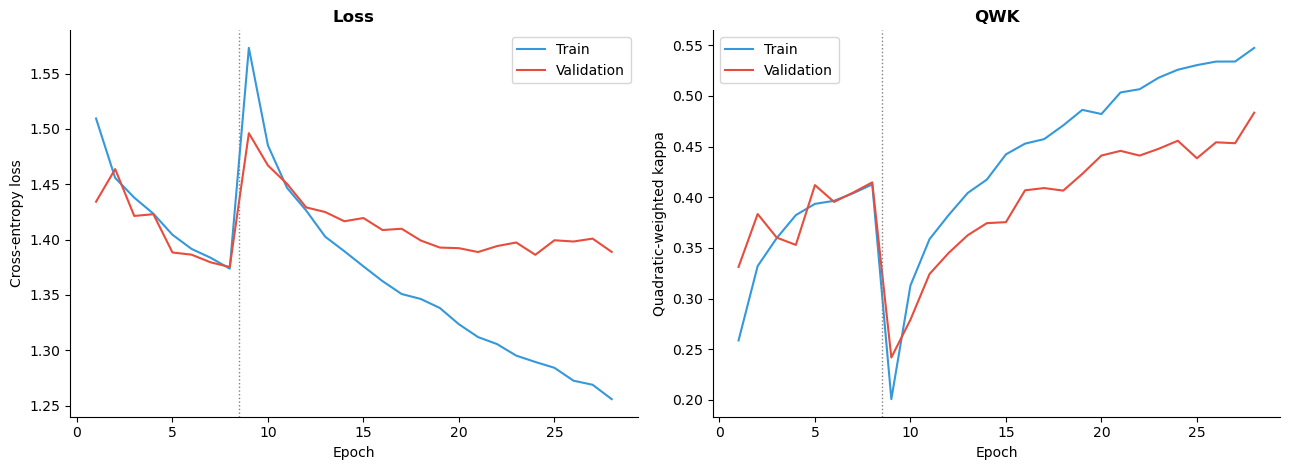

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42/training_curves.png


In [17]:
history_df = pd.DataFrame(history)
phase_transition_epoch = (
    history_df.loc[history_df["phase"] == 1, "global_epoch"].max()
    if (history_df["phase"] == 1).any() else None
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(history_df["global_epoch"], history_df["train_loss"], label="Train", color="#3498DB")
axes[0].plot(history_df["global_epoch"], history_df["val_loss"], label="Validation", color="#E74C3C")
if phase_transition_epoch is not None:
    axes[0].axvline(phase_transition_epoch + 0.5, color="gray", linestyle=":", linewidth=1)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Loss", fontweight="bold")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(history_df["global_epoch"], history_df["train_qwk"], label="Train", color="#3498DB")
axes[1].plot(history_df["global_epoch"], history_df["val_qwk"], label="Validation", color="#E74C3C")
if phase_transition_epoch is not None:
    axes[1].axvline(phase_transition_epoch + 0.5, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Quadratic-weighted kappa")
axes[1].set_title("QWK", fontweight="bold")
axes[1].legend(); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_curves.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'training_curves.png'}")

## 17. Internal-test evaluation

The internal test set is evaluated exactly once, using `FINAL_BEST_PATH` — the checkpoint
selected on validation QWK (with macro-F1 tie-break) across both phases. As with the baseline,
no tuning decision anywhere in this notebook is made using internal-test performance.

In [18]:
model = build_efficientnet_model(pretrained=False).to(device)

final_checkpoint = torch.load(
    FINAL_BEST_PATH,
    map_location=device,
    weights_only=False,
)
model.load_state_dict(final_checkpoint["model_state"])

print(f"Loaded: {FINAL_BEST_PATH.name}")
print(
    f"epoch={final_checkpoint['epoch']}  "
    f"val_qwk={final_checkpoint['val_qwk']:.4f}  "
    f"val_macro_f1={final_checkpoint['val_macro_f1']:.4f}"
)

test_metrics = run_epoch(test_loader, train_mode=False)

test_macro_precision = precision_score(
    test_metrics["labels"],
    test_metrics["preds"],
    average="macro",
    zero_division=0,
)

test_macro_recall = recall_score(
    test_metrics["labels"],
    test_metrics["preds"],
    average="macro",
    zero_division=0,
)

print()
print("=" * 60)
print(f"  {MODEL_NAME} / {RUN_ID} -- INTERNAL TEST SET RESULTS")
print("=" * 60)
print(f"  Test QWK               : {test_metrics['qwk']:.4f}")
print(f"  Test accuracy           : {test_metrics['accuracy']:.4f}")
print(f"  Test balanced accuracy  : {test_metrics['balanced_accuracy']:.4f}")
print(f"  Test macro F1           : {test_metrics['macro_f1']:.4f}")
print(f"  Test macro precision    : {test_macro_precision:.4f}")
print(f"  Test macro recall       : {test_macro_recall:.4f}")
print()
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    digits=3,
    zero_division=0,
))

Loaded: best_model.pt
epoch=28  val_qwk=0.4835  val_macro_f1=0.3768


eval:   0%|          | 0/330 [00:00<?, ?it/s]


  efficientnet_b4 / exp02_p1_clipped_weighted_ce_earlystop_seed42 -- INTERNAL TEST SET RESULTS
  Test QWK               : 0.4920
  Test accuracy           : 0.7182
  Test balanced accuracy  : 0.4066
  Test macro F1           : 0.4046
  Test macro precision    : 0.4176
  Test macro recall       : 0.4066

                  precision    recall  f1-score   support

           No DR      0.807     0.898     0.850      3875
            Mild      0.140     0.090     0.110       366
        Moderate      0.389     0.222     0.282       794
          Severe      0.322     0.419     0.364       136
Proliferative DR      0.430     0.404     0.417        99

        accuracy                          0.718      5270
       macro avg      0.418     0.407     0.405      5270
    weighted avg      0.678     0.718     0.692      5270



## 18. Confusion matrices and per-class metrics

Same form as the baseline's — raw-count and row-normalised confusion matrices, plus a
per-class precision/recall/F1 bar chart — so the two experiments' per-class behaviour can be
compared directly. This is the figure that will show most clearly whether removing WRS and
switching to clipped weighted cross-entropy actually fixed the baseline's "Mild"-class
precision problem, or just moved it somewhere else.

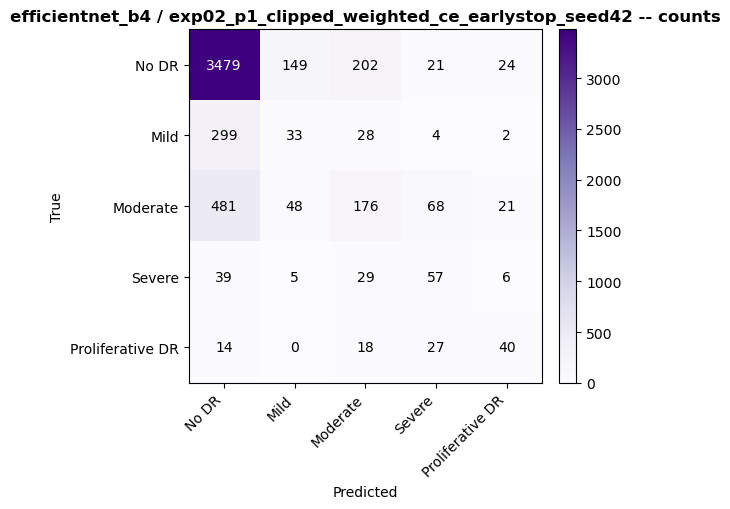

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42/confusion_matrix_counts.png


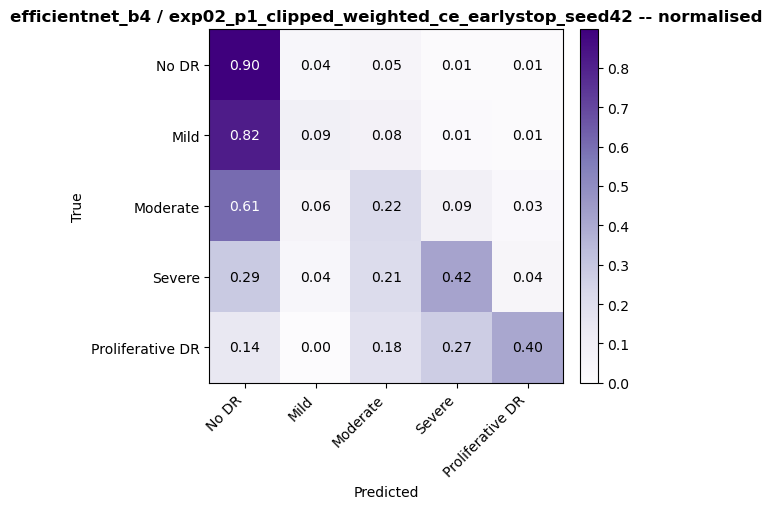

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42/confusion_matrix_normalised.png


In [19]:
cm_counts = confusion_matrix(test_metrics["labels"], test_metrics["preds"])
cm_normalised = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

for data, title, fmt, filename in [
    (cm_counts, f"{MODEL_NAME} / {RUN_ID} -- counts", "d", "confusion_matrix_counts.png"),
    (cm_normalised, f"{MODEL_NAME} / {RUN_ID} -- normalised", ".2f", "confusion_matrix_normalised.png"),
]:
    fig, ax = plt.subplots(figsize=(6, 5.2))
    im = ax.imshow(data, interpolation="nearest", cmap="Purples")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")

    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i, format(data[i, j], fmt),
                ha="center", va="center",
                color="white" if data[i, j] > thresh else "black",
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {FIGURE_DIR / filename}")

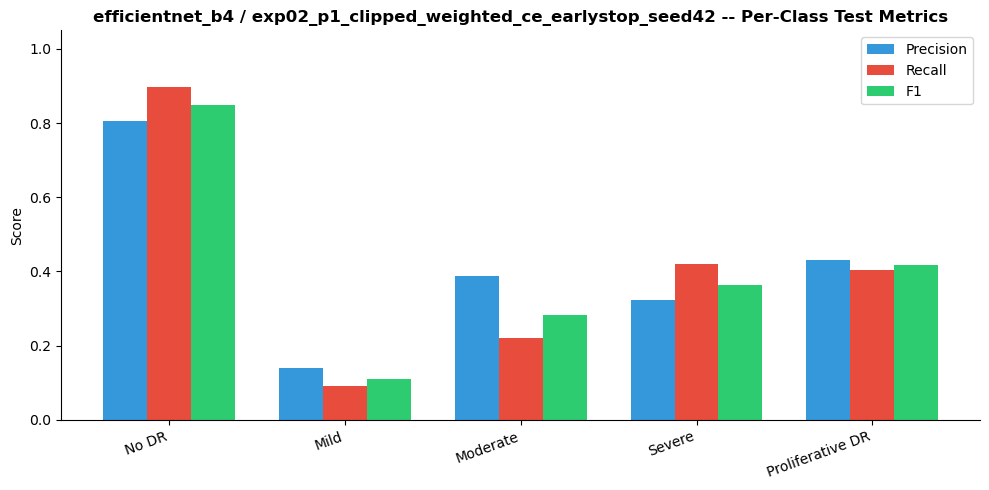

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/figures/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42/per_class_metrics.png


In [20]:
per_class_precision = precision_score(
    test_metrics["labels"], test_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_recall = recall_score(
    test_metrics["labels"], test_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)
per_class_f1 = f1_score(
    test_metrics["labels"], test_metrics["preds"],
    average=None, labels=list(range(NUM_CLASSES)), zero_division=0,
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_CLASSES)
w = 0.25

ax.bar(x - w, per_class_precision, w, label="Precision", color="#3498DB")
ax.bar(x, per_class_recall, w, label="Recall", color="#E74C3C")
ax.bar(x + w, per_class_f1, w, label="F1", color="#2ECC71")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title(f"{MODEL_NAME} / {RUN_ID} -- Per-Class Test Metrics", fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "per_class_metrics.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIGURE_DIR / 'per_class_metrics.png'}")

## 19. Save predictions and metrics

Same three artefacts as the baseline: `best_metrics.json` (the validation metrics the
checkpoint was actually selected on), `test_metrics.json` (the one-off internal-test metrics),
and a per-image prediction CSV matching every test prediction back to its `image`,
`patient_id` and `eye`. `training_history.csv` was already written incrementally in Sections
13 and 15.

In [21]:
best_metrics = {
    "epoch": final_checkpoint["epoch"],
    "phase": final_checkpoint["phase"],
    "val_loss": final_checkpoint["val_loss"],
    "val_accuracy": final_checkpoint["val_accuracy"],
    "val_balanced_accuracy": final_checkpoint["val_balanced_accuracy"],
    "val_macro_f1": final_checkpoint["val_macro_f1"],
    "val_qwk": final_checkpoint["val_qwk"],
}
best_metrics_path = RUN_LOG_DIR / "best_metrics.json"
with open(best_metrics_path, "w") as f:
    json.dump(best_metrics, f, indent=2)
print(f"Saved -> {best_metrics_path}")

test_metrics_summary = {
    "loss": test_metrics["loss"],
    "accuracy": test_metrics["accuracy"],
    "balanced_accuracy": test_metrics["balanced_accuracy"],
    "macro_f1": test_metrics["macro_f1"],
    "macro_precision": test_macro_precision,
    "macro_recall": test_macro_recall,
    "qwk": test_metrics["qwk"],
    "per_class_precision": per_class_precision.tolist(),
    "per_class_recall": per_class_recall.tolist(),
    "per_class_f1": per_class_f1.tolist(),
}
test_metrics_path = RUN_LOG_DIR / "test_metrics.json"
with open(test_metrics_path, "w") as f:
    json.dump(test_metrics_summary, f, indent=2)
print(f"Saved -> {test_metrics_path}")

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42/best_metrics.json
Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/logs/efficientnet_b4/exp02_p1_clipped_weighted_ce_earlystop_seed42/test_metrics.json


In [22]:
pred_rows = test_df.iloc[test_metrics["indices"]].reset_index(drop=True).copy()
pred_rows["true_label"] = test_metrics["labels"]
pred_rows["predicted_label"] = test_metrics["preds"]

probs_array = np.array(test_metrics["probs"])
for grade in range(NUM_CLASSES):
    pred_rows[f"prob_grade_{grade}"] = probs_array[:, grade]

pred_rows["correct"] = pred_rows["true_label"] == pred_rows["predicted_label"]

prediction_columns = [
    "image",
    "patient_id",
    "eye",
    "true_label",
    "predicted_label",
    "prob_grade_0",
    "prob_grade_1",
    "prob_grade_2",
    "prob_grade_3",
    "prob_grade_4",
    "correct",
]

predictions_path = PREDICTION_DIR / f"{MODEL_NAME}_exp02_internal_test_predictions.csv"
pred_rows[prediction_columns].to_csv(predictions_path, index=False)

print(f"Saved -> {predictions_path}  ({len(pred_rows):,} rows)")
pred_rows[prediction_columns].head()

Saved -> /scratch/New AML/EEEM068-LSA-Diabetic-Retinopathy/results/predictions/efficientnet_b4_exp02_internal_test_predictions.csv  (5,270 rows)


,image,patient_id,eye,true_label,predicted_label,prob_grade_0,prob_grade_1,prob_grade_2,prob_grade_3,prob_grade_4,correct
0,10_left,10,left,0,0,0.507324,0.071716,0.171265,0.152100,0.097717,True
1,10_right,10,right,0,2,0.359619,0.069336,0.405273,0.043823,0.121948,False
2,21_left,21,left,0,0,0.651367,0.174683,0.104858,0.037140,0.031891,True
3,21_right,21,right,0,0,0.371338,0.358887,0.170654,0.069214,0.029800,True
4,46_left,46,left,0,0,0.557129,0.067200,0.062042,0.047455,0.266357,True


## 20. Final observations

Training completed successfully using the leakage-free patient-grouped split.
Phase 1 reached its best validation QWK of 0.4147 at epoch 8. After reloading
the best Phase-1 checkpoint, full fine-tuning initially caused a sharp
performance reduction, but the model gradually recovered. The final selected
checkpoint occurred at global epoch 28, corresponding to Phase 2 epoch 20,
with validation QWK 0.4835 and validation macro F1 0.3768.

On the locked internal test set, Experiment 02 achieved QWK 0.4920, accuracy
0.7182, balanced accuracy 0.4066 and macro F1 0.4046. Compared with Experiment
01, accuracy increased substantially from 0.5689 to 0.7182 and macro precision
increased from 0.3801 to 0.4176. However, test QWK decreased from 0.5179 to
0.4920, balanced accuracy decreased from 0.4788 to 0.4066 and macro recall
decreased from 0.4788 to 0.4066.

Removing WeightedRandomSampler reduced the previous tendency to over-predict
the Mild class: Mild precision increased from approximately 0.094 to 0.140.
However, Mild recall fell to 0.090 and Mild F1 fell to 0.110. The confusion
matrix shows that 299 of 366 Mild cases and 481 of 794 Moderate cases were
classified as No DR. Therefore, Experiment 02 shifted towards the majority
class and improved overall accuracy without improving balanced ordinal
classification.

Under the predefined model-selection protocol, validation QWK is the primary
criterion and macro F1 is the tie-break. Experiment 01 remains the selected
EfficientNet-B4 configuration because its validation QWK of 0.5209 is higher
than Experiment 02's 0.4835. Experiment 02 is retained as an informative
alternative showing the trade-off between majority-class accuracy and
minority-grade sensitivity.

The best Experiment-02 checkpoint occurred at the final permitted Phase-2
epoch, suggesting that this configuration may not have fully converged within
the 20-epoch fine-tuning budget. Nevertheless, no additional training was
performed because the predefined experiment budget was preserved.